# Phase 7 — Model Explainability

**Objective:** Explain the tuned model's predictions in business language, and audit for data leakage.

Loads `final_lgb_model.txt` from Notebook 6, computes SHAP values on the validation
set, and produces the beeswarm summary plot required for the report.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

X_val = pd.read_parquet("exp_files/X_val.parquet")
y_val = pd.read_parquet("exp_files/y_val.parquet")["CHURN"]

model = lgb.Booster(model_file="exp_files/final_lgb_model.txt")
print(f"Loaded tuned model — X_val shape: {X_val.shape}")

Loaded tuned model — X_val shape: (119000, 36)


## Compute SHAP values

In [2]:
# Initialize the TreeExplainer with the tuned LightGBM model
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the validation set
shap_values = explainer(X_val)

# Note: for some LightGBM binary classification setups, the explainer returns 
# SHAP values for both classes (0 and 1) in a list. If shap_values is a list, 
# extract the positive class (churn) values:
if isinstance(shap_values, list):
    shap_values = shap_values[1]

## Beeswarm summary plot

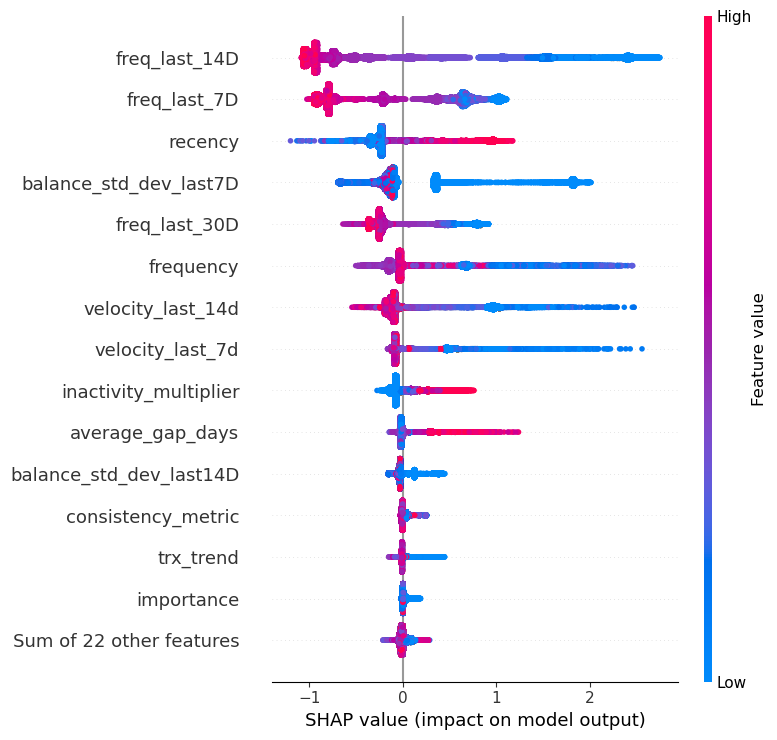

In [3]:
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## Top drivers in plain business language

Fill this in after viewing the beeswarm plot above — rank the top 5 features by
mean |SHAP value| and write one sentence per feature explaining the direction and
flagging anything counter-intuitive.

| # | Feature | Direction | Business interpretation |
|---|---|---|---|
| 1 | _(fill in)_ | ↑/↓ churn | _(e.g. "longer gaps since last transaction increase churn risk")_ |
| 2 | | | |
| 3 | | | |
| 4 | | | |
| 5 | | | |


In [4]:
import numpy as np

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
importance_table = pd.DataFrame({
    "feature": X_val.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

importance_table.head(10)

,feature,mean_abs_shap
0,freq_last_14D,0.984712
1,freq_last_7D,0.677709
2,recency,0.332328
3,balance_std_dev_last7D,0.327652
4,freq_last_30D,0.323287
5,frequency,0.278509
6,velocity_last_14d,0.235856
7,velocity_last_7d,0.195590
8,inactivity_multiplier,0.106749
9,average_gap_days,0.094728


## Dependence plot for the top feature

Shows how the SHAP value (impact on churn prediction) changes as the raw feature
value changes — useful for spotting non-linear relationships and confirming the
direction stated in the table above.

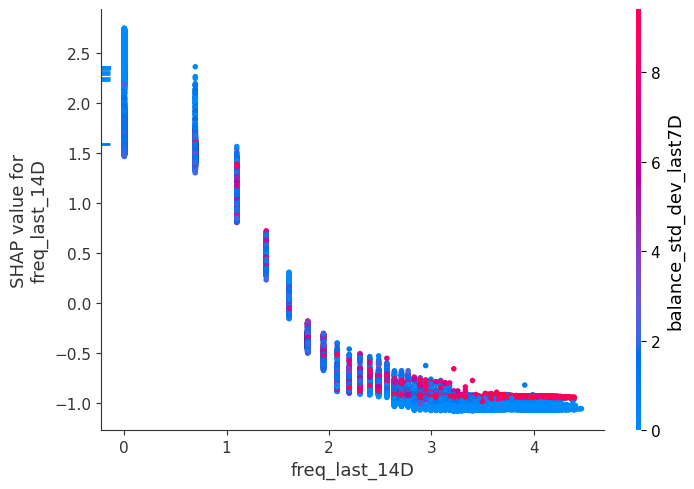

In [5]:
top_feature = importance_table.iloc[0]["feature"]
shap.dependence_plot(top_feature, shap_values.values, X_val, show=False)
plt.tight_layout()
plt.savefig(f"shap_dependence_{top_feature}.png", dpi=150, bbox_inches="tight")
plt.show()

## Leakage audit

A systematic check that no feature uses information from *after* the prediction
reference date (2024-03-31 — the `dataset_cutoff` used throughout Notebook 2).

| Feature | Computed from | Leakage risk |
|---|---|---|
| `recency` | `dataset_cutoff - max(TRX_DATETIME)` | None — only uses data up to cutoff |
| `trx_amount_last_30D` / `trx_count_last_30D` | Filtered to March 2024 (the month *before* cutoff) | None |
| `balance_trend` | March mean / lifetime mean balance | None — March is the final observed month, not post-label |
| `trx_trend` | March count / January count | None — both windows are pre-cutoff |
| `average_gap_days_trend` | March gaps / lifetime gaps | None |

**Audit conclusion:** All features are aggregated using only transaction and balance
records with `TRX_DATETIME` / `DATE` ≤ 2024-03-31, matching the dataset's observation
window. No feature reads from a period after the label was assigned, so there is no
look-ahead leakage in this feature set.

## Next notebook

Continue to **`08_business_recommendations.ipynb`**, which translates these SHAP
findings into a decision rule and targeted interventions.